In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Plot-Stil
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

# Daten laden
df = pd.read_csv("lmu_muenchen_2005_2025_clean.csv", index_col="Datum", parse_dates=True)

print(df.shape)
print(df.dtypes)
df.head()

(7447, 6)
T_max    float64
T_min    float64
Regen    float64
p_max    float64
p_min    float64
Sonne    float64
dtype: object


,T_max,T_min,Regen,p_max,p_min,Sonne
Datum,,,,,,
2005-01-01,7.3,3.2,0.0,966.1,961.0,1.4
2005-01-02,8.0,1.2,1.0,967.8,957.6,0.0
2005-01-03,4.0,1.4,0.1,972.6,967.8,0.0
2005-01-04,6.8,3.3,0.0,971.1,967.3,4.3
2005-01-05,8.0,2.7,0.0,969.0,964.1,2.2


In [2]:
# Phase 1 — Überblick & Struktur
print("=== Zeitraum ===")
print(f"Von: {df.index.min().date()}  Bis: {df.index.max().date()}")
print(f"Erwartete Tage: {len(pd.date_range(df.index.min(), df.index.max()))}")
print(f"Vorhandene Tage: {len(df)}")
print(f"Fehlende Tage: {len(pd.date_range(df.index.min(), df.index.max())) - len(df)}")

print("\n=== Duplikate ===")
print(f"Doppelte Datumseinträge: {df.index.duplicated().sum()}")

print("\n=== Statistik ===")
df.describe().round(2)

=== Zeitraum ===
Von: 2005-01-01  Bis: 2025-12-31
Erwartete Tage: 7670
Vorhandene Tage: 7447
Fehlende Tage: 223

=== Duplikate ===
Doppelte Datumseinträge: 0

=== Statistik ===


,T_max,T_min,Regen,p_max,p_min,Sonne
count,7447.00,7447.00,7447.0,7447.00,7447.00,7447.00
mean,14.55,7.15,1.9,959.13,954.30,1.66
std,8.99,6.94,4.5,7.01,8.05,2.74
min,-9.80,-15.20,0.0,923.10,916.40,0.00
25%,7.50,1.70,0.0,955.20,950.00,0.00
50%,14.70,7.30,0.0,959.40,955.10,0.00
75%,21.60,12.70,1.6,963.60,959.50,2.50
max,36.20,23.10,81.4,982.10,979.10,15.00


In [3]:
# Welche Tage fehlen?
voller_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
fehlende_tage = voller_index.difference(df.index)

print(f"Fehlende Tage gesamt: {len(fehlende_tage)}")
print(f"\nFehlende Tage pro Jahr:")
print(pd.Series(fehlende_tage).dt.year.value_counts().sort_index())

Fehlende Tage gesamt: 223

Fehlende Tage pro Jahr:
2005     4
2006    14
2007     7
2008     5
2009    24
2010    12
2011     8
2012    12
2013     6
2014     6
2015    14
2016    11
2017    11
2018    11
2019    38
2020     8
2021    15
2022     3
2023     2
2024     7
2025     5
Name: count, dtype: int64


In [4]:
for jahr in [2009, 2019]:
    luecken = fehlende_tage[fehlende_tage.year == jahr]
    print(f"\n=== {jahr} — {len(luecken)} fehlende Tage ===")
    print(f"Erste Lücke: {luecken.min().date()}")
    print(f"Letzte Lücke: {luecken.max().date()}")
    # Zusammenhängende Blöcke identifizieren
    luecken_series = pd.Series(luecken)
    gaps = luecken_series.diff().dt.days.fillna(1)
    bloecke = (gaps > 1).sum() + 1
    print(f"Anzahl zusammenhängender Blöcke: {bloecke}")


=== 2009 — 24 fehlende Tage ===
Erste Lücke: 2009-03-04
Letzte Lücke: 2009-12-27
Anzahl zusammenhängender Blöcke: 9

=== 2019 — 38 fehlende Tage ===
Erste Lücke: 2019-03-02
Letzte Lücke: 2019-08-11
Anzahl zusammenhängender Blöcke: 4


In [5]:
# Lückenlosen Index erzwingen
df = df.reindex(voller_index)

# Flag-Spalte BEVOR wir interpolieren
df["ist_interpoliert"] = df["T_max"].isna().astype(int)

# Zeitliche Interpolation
df = df.interpolate(method="time")

# Kontrolle
print(f"Shape nach Reindex: {df.shape}")
print(f"Verbleibende NaN: {df.isna().sum().sum()}")
print(f"Interpolierte Tage gesamt: {df['ist_interpoliert'].sum()}")

Shape nach Reindex: (7670, 7)
Verbleibende NaN: 0
Interpolierte Tage gesamt: 223


In [6]:
df.to_csv("lmu_muenchen_2005_2025_clean.csv")
print("Gespeichert.")

Gespeichert.


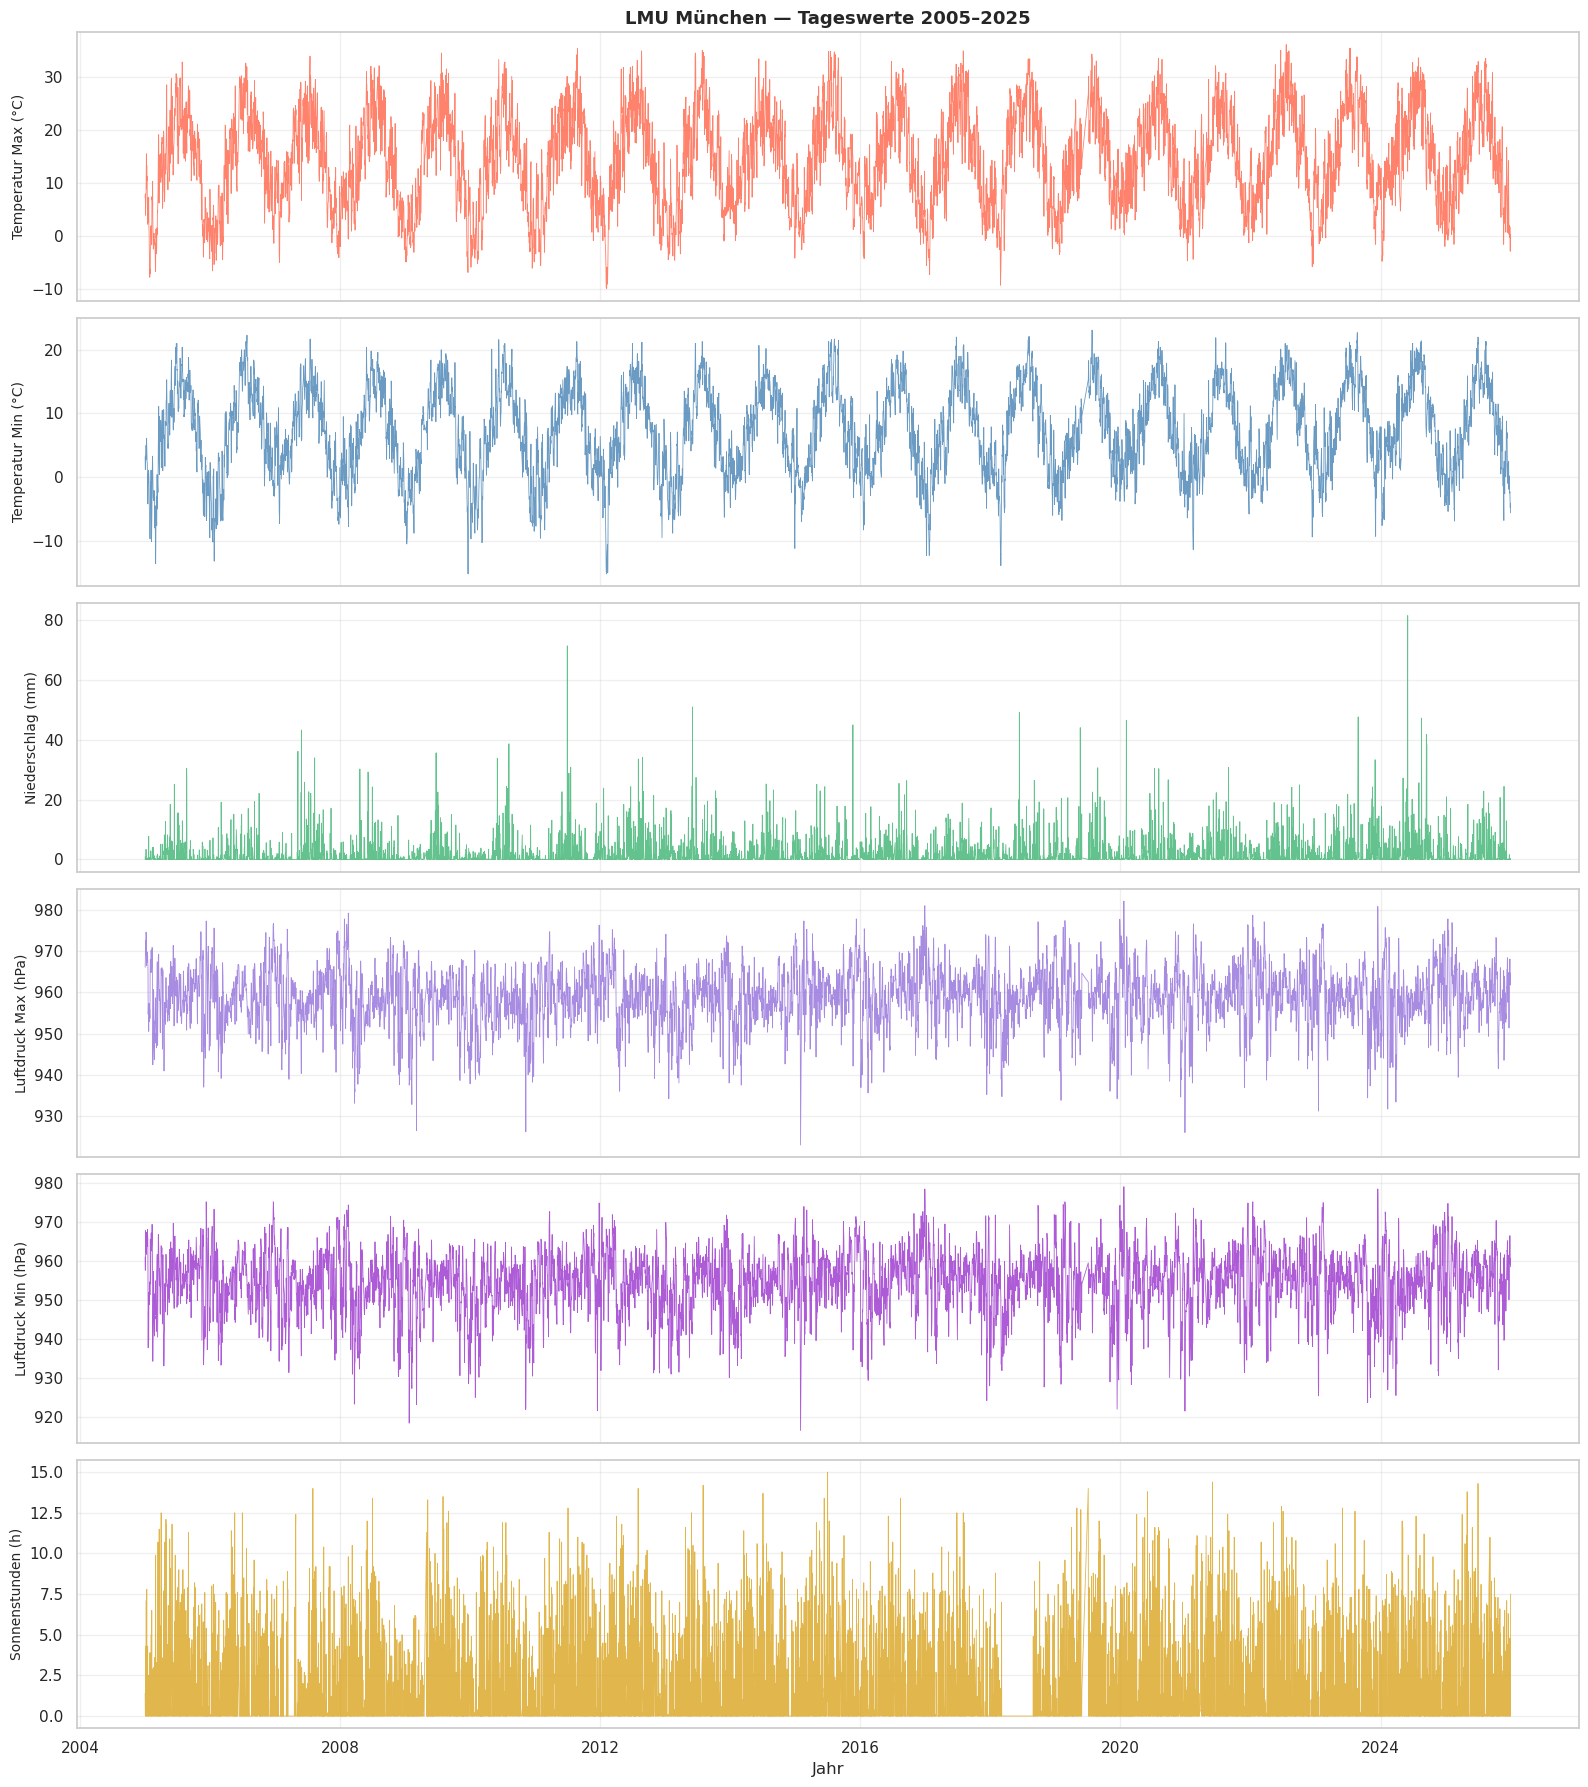

In [7]:
# Phase 2.3 — Zeitreihenplot aller Variablen
fig, axes = plt.subplots(6, 1, figsize=(16, 18), sharex=True)

variablen = [
    ("T_max", "Temperatur Max (°C)", "tomato"),
    ("T_min", "Temperatur Min (°C)", "steelblue"),
    ("Regen", "Niederschlag (mm)", "mediumseagreen"),
    ("p_max", "Luftdruck Max (hPa)", "mediumpurple"),
    ("p_min", "Luftdruck Min (hPa)", "darkorchid"),
    ("Sonne", "Sonnenstunden (h)", "goldenrod"),
]

for ax, (col, label, farbe) in zip(axes, variablen):
    ax.plot(df.index, df[col], color=farbe, linewidth=0.6, alpha=0.8)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title("LMU München — Tageswerte 2005–2025", fontsize=13, fontweight="bold")
axes[-1].set_xlabel("Jahr")
plt.tight_layout()
plt.show()

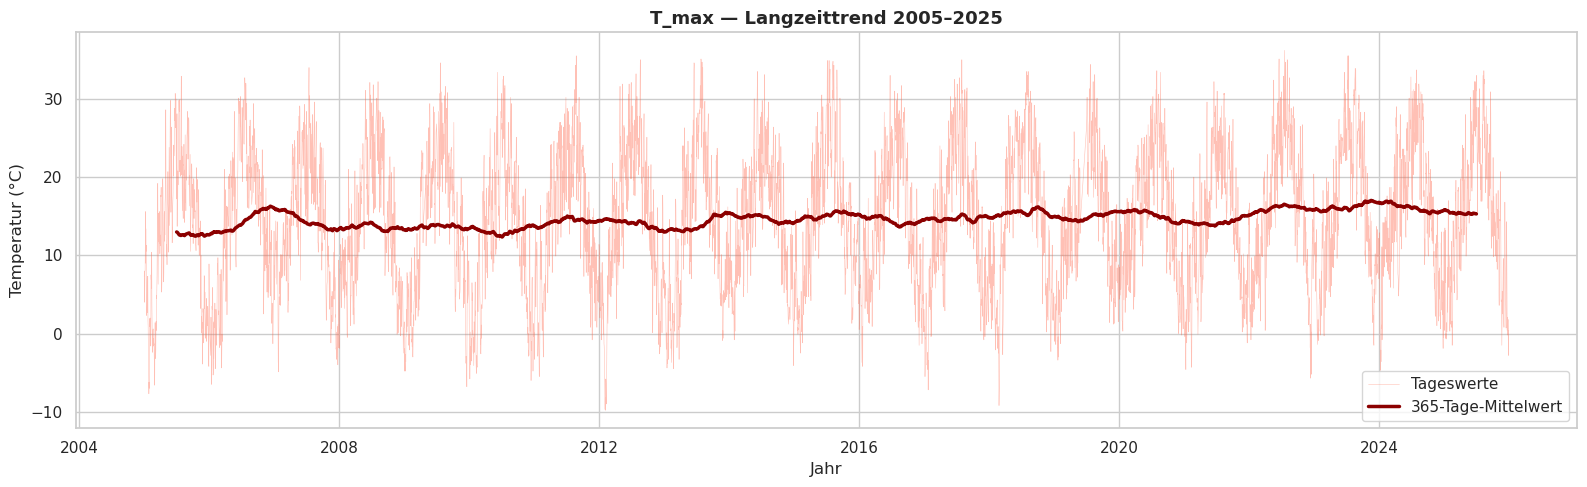

In [8]:
# Phase 2.5 — Jahrestrend T_max mit rollendem Mittelwert
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.index, df["T_max"], color="tomato", linewidth=0.4, alpha=0.4, label="Tageswerte")
ax.plot(df.index, df["T_max"].rolling(365, center=True).mean(),
        color="darkred", linewidth=2.5, label="365-Tage-Mittelwert")

ax.set_title("T_max — Langzeittrend 2005–2025", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Jahr")
ax.legend()
plt.tight_layout()
plt.show()

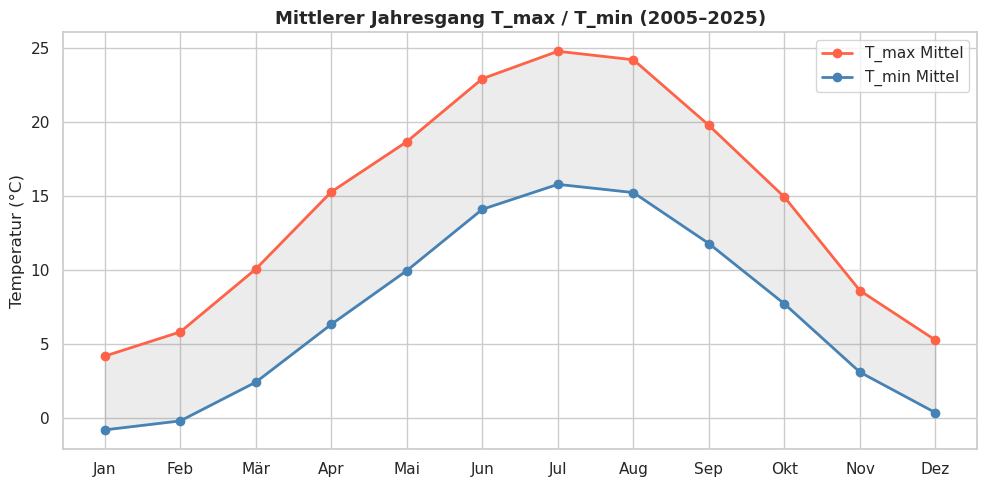

In [9]:
# Phase 2.4 — Mittlerer Jahresgang
df["Monat"] = df.index.month
jahresgang = df.groupby("Monat")[["T_max", "T_min"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(jahresgang.index, jahresgang["T_max"], color="tomato",
        marker="o", linewidth=2, label="T_max Mittel")
ax.plot(jahresgang.index, jahresgang["T_min"], color="steelblue",
        marker="o", linewidth=2, label="T_min Mittel")
ax.fill_between(jahresgang.index, jahresgang["T_min"], jahresgang["T_max"],
                alpha=0.15, color="gray")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mär","Apr","Mai","Jun",
                    "Jul","Aug","Sep","Okt","Nov","Dez"])
ax.set_title("Mittlerer Jahresgang T_max / T_min (2005–2025)", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

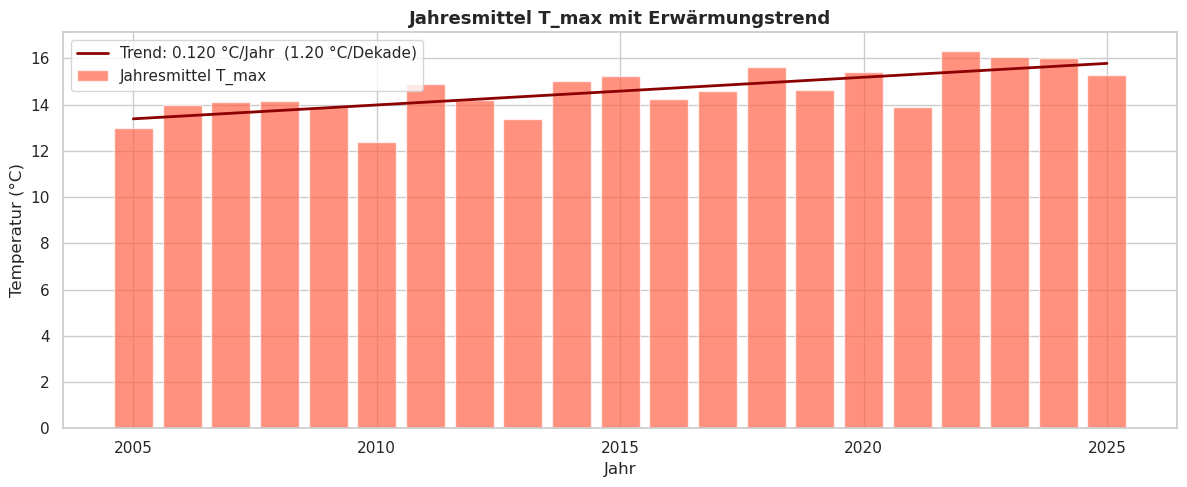

In [10]:
import numpy as np

# Jahresmittel berechnen
jahresmittel = df.groupby(df.index.year)["T_max"].mean()

# Lineare Regression
x = jahresmittel.index.values
y = jahresmittel.values
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, y, color="tomato", alpha=0.7, label="Jahresmittel T_max")
ax.plot(x, m * x + b, color="darkred", linewidth=2,
        label=f"Trend: {m:.3f} °C/Jahr  ({m*10:.2f} °C/Dekade)")

ax.set_title("Jahresmittel T_max mit Erwärmungstrend", fontsize=13, fontweight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Jahr")
ax.legend()
plt.tight_layout()
plt.show()

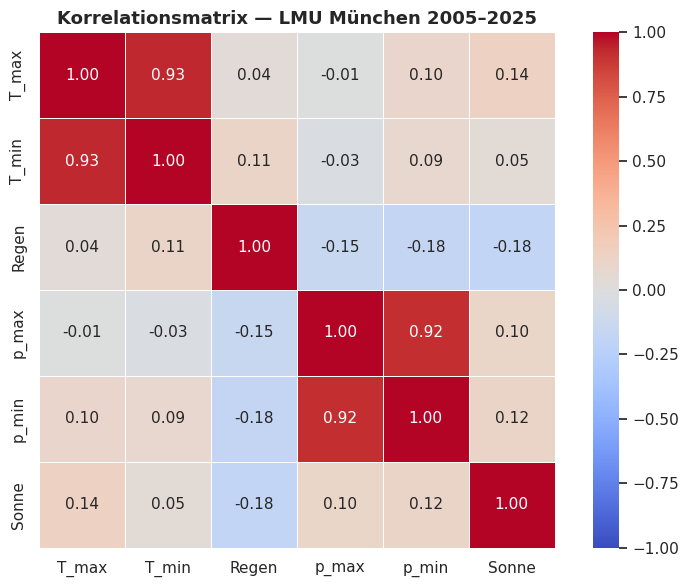

In [11]:
# Phase 3.1 — Korrelationsmatrix
fig, ax = plt.subplots(figsize=(8, 6))

korr = df[["T_max", "T_min", "Regen", "p_max", "p_min", "Sonne"]].corr()

sns.heatmap(korr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)

ax.set_title("Korrelationsmatrix — LMU München 2005–2025",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

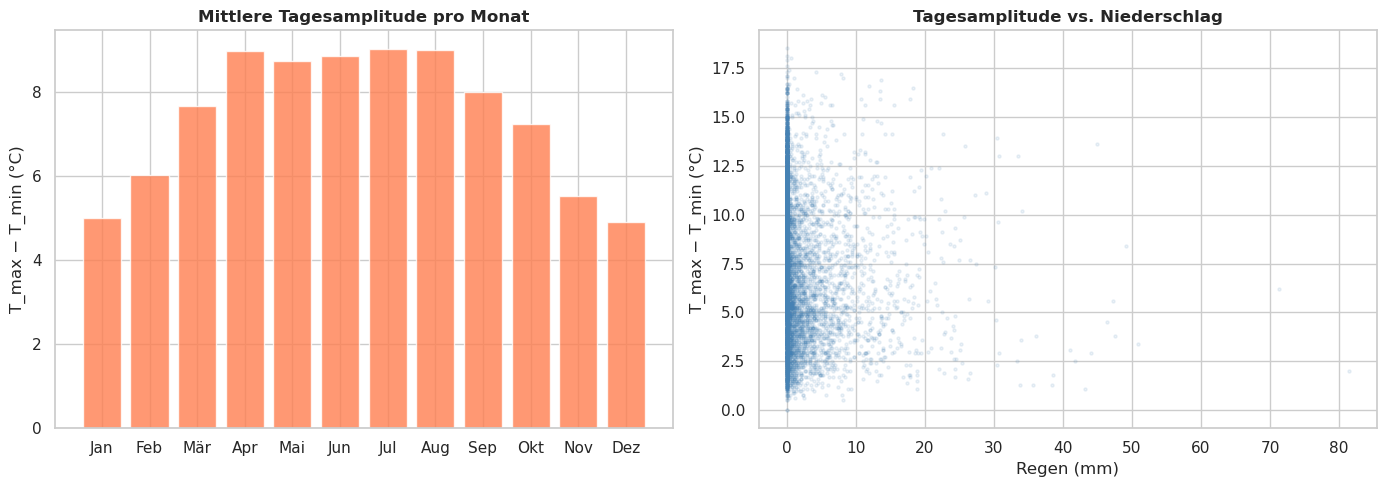

In [12]:
# Phase 3.5 — Tagesamplitude
df["T_amp"] = df["T_max"] - df["T_min"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Jahresgang der Amplitude
amp_monat = df.groupby(df.index.month)["T_amp"].mean()
axes[0].bar(range(1, 13), amp_monat, color="coral", alpha=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Feb","Mär","Apr","Mai","Jun",
                          "Jul","Aug","Sep","Okt","Nov","Dez"])
axes[0].set_title("Mittlere Tagesamplitude pro Monat", fontweight="bold")
axes[0].set_ylabel("T_max − T_min (°C)")

# Amplitude vs. Regen
axes[1].scatter(df["Regen"], df["T_amp"], alpha=0.1, color="steelblue", s=5)
axes[1].set_title("Tagesamplitude vs. Niederschlag", fontweight="bold")
axes[1].set_xlabel("Regen (mm)")
axes[1].set_ylabel("T_max − T_min (°C)")

plt.tight_layout()
plt.show()

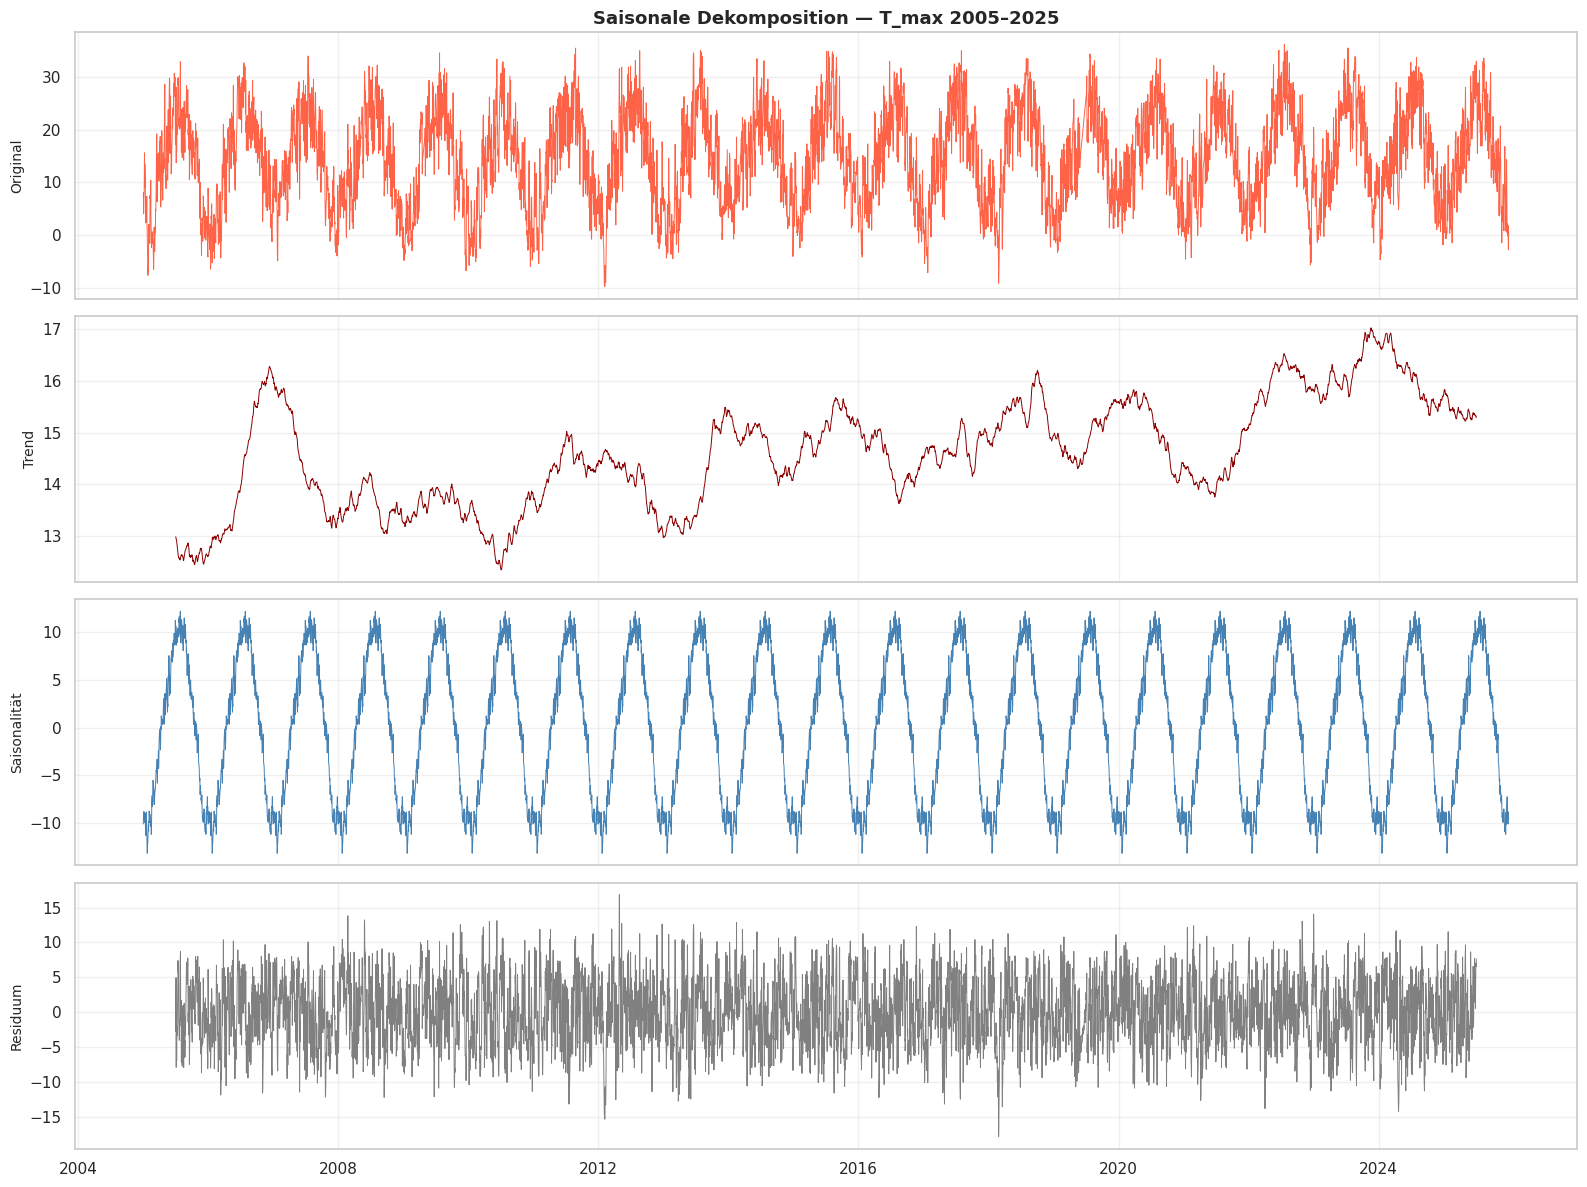

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Dekomposition auf T_max (365-Tage-Periode)
result = seasonal_decompose(df["T_max"], model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
labels = ["Original", "Trend", "Saisonalität", "Residuum"]
components = [result.observed, result.trend, result.seasonal, result.resid]
colors = ["tomato", "darkred", "steelblue", "gray"]

for ax, label, comp, farbe in zip(axes, labels, components, colors):
    ax.plot(comp, color=farbe, linewidth=0.7)
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Saisonale Dekomposition — T_max 2005–2025",
                  fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

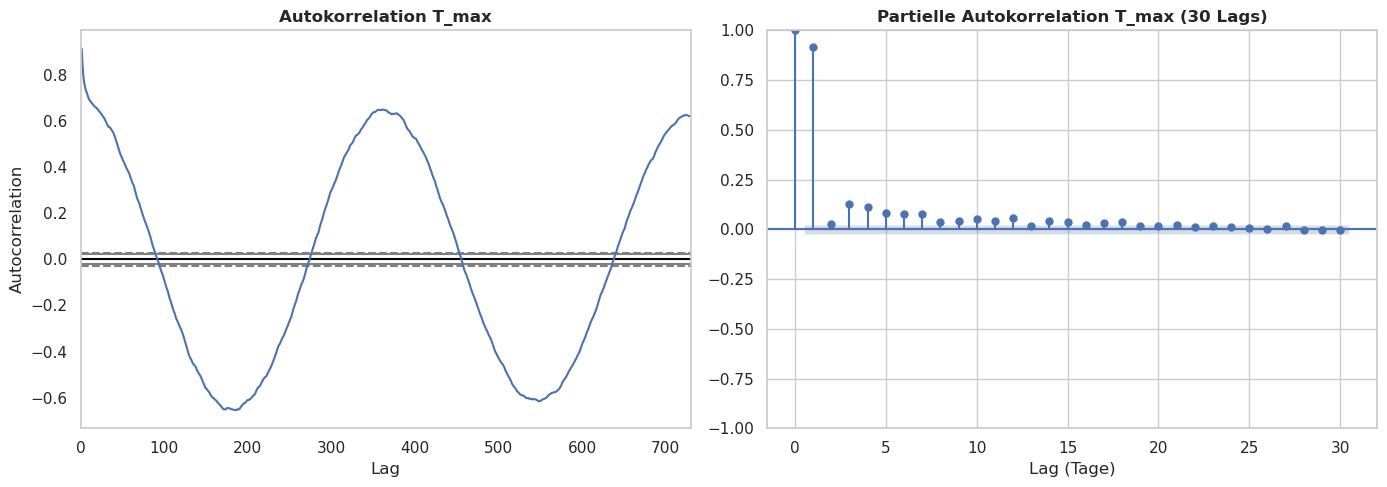

In [14]:
# Phase 4.3 — Autokorrelation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.plotting.autocorrelation_plot(df["T_max"], ax=axes[0])
axes[0].set_title("Autokorrelation T_max", fontweight="bold")
axes[0].set_xlim(0, 730)  # 2 Jahre

# Partielle Autokorrelation
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df["T_max"], lags=30, ax=axes[1], method="ywm")
axes[1].set_title("Partielle Autokorrelation T_max (30 Lags)", fontweight="bold")
axes[1].set_xlabel("Lag (Tage)")

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["T_max"].dropna())
print(f"ADF-Statistik:  {result[0]:.4f}")
print(f"p-Wert:         {result[1]:.6f}")
print(f"Kritische Werte:")
for key, val in result[4].items():
    print(f"  {key}: {val:.4f}")

if result[1] < 0.05:
    print("\n→ Zeitreihe ist STATIONÄR (p < 0.05)")
else:
    print("\n→ Zeitreihe ist NICHT stationär — Differenzierung nötig")

ADF-Statistik:  -5.9472
p-Wert:         0.000000
Kritische Werte:
  1%: -3.4312
  5%: -2.8619
  10%: -2.5670

→ Zeitreihe ist STATIONÄR (p < 0.05)
